# Skin Lesion Bias Reduction using Conditional GANs

## Project Overview

This notebook presents a comprehensive solution for addressing dataset bias in skin lesion classification using **Conditional Generative Adversarial Networks (cGANs)**.

### Problem Statement

Medical image datasets often suffer from significant bias in skin tone representation. The Fitzpatrick17k dataset, while valuable, has an imbalanced distribution across the Fitzpatrick skin tone scale (1-6), with darker skin tones (5 & 6) being significantly underrepresented. This bias can lead to:

- **Unfair AI models** that perform poorly on underrepresented groups
- **Health disparities** in automated diagnosis systems
- **Biased medical research** outcomes

### Our Solution

We use a **Conditional GAN (cGAN)** to generate synthetic skin lesion images for underrepresented skin tones, specifically:

1. **Train** a cGAN on the existing Fitzpatrick17k dataset
2. **Generate** high-quality synthetic images for Fitzpatrick skin tones 5 & 6
3. **Augment** the original dataset to create a balanced training set
4. **Improve** classification model fairness across all skin tones


## 1. Setup & Imports

First, let's install required packages and import necessary libraries.

In [1]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision pandas pillow matplotlib tqdm tensorboard requests

import os
import sys
from pathlib import Path
from datetime import datetime
from typing import Tuple, Optional, Dict, Any, Union
import argparse
import time

# Data handling
import pandas as pd
import numpy as np
from PIL import Image
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Tensorboard (optional)
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    print("TensorBoard not available. Install with: pip install tensorboard")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using: {device}")

PyTorch version: 2.9.0+cu126
Using: cuda


In [2]:
!nvidia-smi

Mon Feb  9 23:48:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   34C    P0             67W /  700W |       3MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

---

## 2. Data Processing

### Dataset Overview: Fitzpatrick17k

The Fitzpatrick17k dataset contains dermatology images labeled with:
- **Fitzpatrick Skin Tone** (1-6): From lightest to darkest
- **Lesion Type**: Benign, Malignant, or Non-neoplastic

### Data Pipeline Components

1. **Label Encoding**: Map categorical labels to numerical indices
2. **Dataset Class**: PyTorch Dataset for loading and transforming images
3. **Data Augmentation**: Random flips and rotations to improve model robustness
4. **DataLoader**: Efficient batching and parallel loading

#### Label Encoding

In [ ]:

# Map Fitzpatrick scale (1-6) to indices (0-5)
FITZPATRICK_ENCODING = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
FITZPATRICK_DECODING = {v: k for k, v in FITZPATRICK_ENCODING.items()}

# Map lesion types to indices
LESION_TYPE_ENCODING = {"benign": 0, "malignant": 1, "non-neoplastic": 2}
LESION_TYPE_DECODING = {v: k for k, v in LESION_TYPE_ENCODING.items()}

# Number of classes
NUM_SKIN_TONES = 6
NUM_LESION_TYPES = 3

print("Label Encodings:")
print(f"  Skin Tones: {NUM_SKIN_TONES} classes (Fitzpatrick 1-6)")
print(f"  Lesion Types: {NUM_LESION_TYPES} classes (benign, malignant, non-neoplastic)")

Label Encodings:
  Skin Tones: 6 classes (Fitzpatrick 1-6)
  Lesion Types: 3 classes (benign, malignant, non-neoplastic)


#### Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    """
    Custom PyTorch Dataset for Fitzpatrick17k skin lesion images.
    
    Features:
    - Loads images from disk based on CSV metadata
    - Filters invalid skin tone labels (-1)
    - Supports optional filtering by skin tone and lesion type
    - Applies transforms (resize, augmentation, normalization)
    - Returns (image, skin_tone_label, lesion_type_label)
    """
    
    def __init__(
        self,
        csv_path: str,
        image_dir: str,
        transform: Optional[transforms.Compose] = None,
        filter_skin_tones: Optional[list] = None,
        filter_lesion_types: Optional[list] = None
    ):
        self.image_dir = image_dir
        
        # Load CSV and remove invalid entries
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df["fitzpatrick_scale"] != -1].reset_index(drop=True)
        
        # Apply optional filters
        if filter_skin_tones is not None:
            self.df = self.df[
                self.df["fitzpatrick_scale"].isin(filter_skin_tones)
            ].reset_index(drop=True)
            
        if filter_lesion_types is not None:
            self.df = self.df[
                self.df["three_partition_label"].isin(filter_lesion_types)
            ].reset_index(drop=True)
        
        # Verify images exist
        self._verify_images()
        
        # Default transform: resize to 64x64, normalize to [-1, 1]
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((64, 64)),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
        else:
            self.transform = transform
    
    def _verify_images(self) -> None:
        """Verify that image files exist and filter out missing ones."""
        valid_indices = []
        for idx, row in self.df.iterrows():
            img_path = os.path.join(self.image_dir, f"{row['md5hash']}.jpg")
            if os.path.exists(img_path):
                valid_indices.append(idx)
        
        if len(valid_indices) < len(self.df):
            print(f"⚠️  Warning: {len(self.df) - len(valid_indices)} images not found. "
                  f"Using {len(valid_indices)} available images.")
            self.df = self.df.loc[valid_indices].reset_index(drop=True)
    
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        
        # Load image
        img_path = os.path.join(self.image_dir, f"{row['md5hash']}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        # Apply transforms
        image = self.transform(image)
        
        # Encode labels
        skin_tone = torch.tensor(
            FITZPATRICK_ENCODING[row["fitzpatrick_scale"]], 
            dtype=torch.long
        )
        lesion_type = torch.tensor(
            LESION_TYPE_ENCODING[row["three_partition_label"]], 
            dtype=torch.long
        )
        
        return image, skin_tone, lesion_type


def get_augmented_transform(image_size: int = 64) -> transforms.Compose:
    """
    Get augmented transforms for training.
    Includes random flips and rotations to improve model generalization.
    """
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


def get_dataloader(
    csv_path: str,
    image_dir: str,
    batch_size: int = 64,
    shuffle: bool = True,
    num_workers: int = 4,
    transform: Optional[transforms.Compose] = None,
    filter_skin_tones: Optional[list] = None,
    filter_lesion_types: Optional[list] = None,
    pin_memory: bool = True
) -> Tuple[DataLoader, SkinLesionDataset]:
    """
    Create a DataLoader for the skin lesion dataset.
    """
    dataset = SkinLesionDataset(
        csv_path=csv_path,
        image_dir=image_dir,
        transform=transform,
        filter_skin_tones=filter_skin_tones,
        filter_lesion_types=filter_lesion_types
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True  # Drop last incomplete batch for stable training
    )
    
    return dataloader, dataset

print(" Data processing classes defined successfully")

 Data processing classes defined successfully


---

## 3. Model Architecture

### Conditional GAN Overview

A **Conditional GAN** extends the standard GAN by conditioning both the generator and discriminator on additional information (in our case, skin tone and lesion type).

<img src="cgan_architecture.png">


#### Generator and Discriminator

In [ ]:
class Generator(nn.Module):
    """
    Conditional Generator using DCGAN architecture.
    
    Takes as input:
    - Random noise vector (latent_dim)
    - Skin tone class (0-5)
    - Lesion type class (0-2)
    
    Outputs:
    - 64x64 RGB image in range [-1, 1]
    
    Architecture:
    - Embedding layers for conditions
    - 5 transposed convolution layers
    - BatchNorm and ReLU activations
    - Tanh output activation
    """
    
    def __init__(self, latent_dim=100, embedding_dim=50, ngf=64):
        super(Generator, self).__init__()
        
        self.latent_dim = latent_dim
        self.embedding_dim = embedding_dim
        
        # Embedding layers for conditional information
        self.skin_tone_embedding = nn.Embedding(NUM_SKIN_TONES, embedding_dim)
        self.lesion_type_embedding = nn.Embedding(NUM_LESION_TYPES, embedding_dim)
        
        # Total input dimension
        self.input_dim = latent_dim + 2 * embedding_dim
        
        # Generator architecture
        self.main = nn.Sequential(
            # Input: (input_dim) -> 4x4
            nn.ConvTranspose2d(self.input_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            # 4x4 -> 8x8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # 8x8 -> 16x16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # 16x16 -> 32x32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # 32x32 -> 64x64
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in range [-1, 1]
        )
    
    def forward(self, noise, skin_tone, lesion_type):
        """
        Args:
            noise: (batch_size, latent_dim) random noise
            skin_tone: (batch_size,) skin tone indices
            lesion_type: (batch_size,) lesion type indices
        
        Returns:
            (batch_size, 3, 64, 64) generated images
        """
        # Get embeddings
        skin_embed = self.skin_tone_embedding(skin_tone)
        lesion_embed = self.lesion_type_embedding(lesion_type)
        
        # Concatenate noise with condition embeddings
        x = torch.cat([noise, skin_embed, lesion_embed], dim=1)
        
        # Reshape for convolutional layers
        x = x.view(-1, self.input_dim, 1, 1)
        
        # Generate image
        return self.main(x)


class Discriminator(nn.Module):
    """
    Conditional Discriminator using DCGAN architecture.
    
    Takes as input:
    - Image (64x64 RGB)
    - Skin tone class (0-5)
    - Lesion type class (0-2)
    
    Outputs:
    - Real/Fake score in range [0, 1]
    
    Architecture:
    - Embedding layers for conditions
    - Condition embeddings added to image channels
    - 5 convolutional layers
    - LeakyReLU activations
    - Sigmoid output activation
    """
    
    def __init__(self, embedding_dim=50, ndf=64):
        super(Discriminator, self).__init__()
        
        self.embedding_dim = embedding_dim
        
        # Embedding layers
        self.skin_tone_embedding = nn.Embedding(NUM_SKIN_TONES, embedding_dim)
        self.lesion_type_embedding = nn.Embedding(NUM_LESION_TYPES, embedding_dim)
        
        # Projection to image space (64x64)
        self.condition_projection = nn.Linear(2 * embedding_dim, 64 * 64)
        
        # Discriminator architecture
        # Input channels: 3 (RGB) + 1 (condition map) = 4
        self.main = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(4, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 32x32 -> 16x16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 16x16 -> 8x8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 8x8 -> 4x4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 4x4 -> 1x1
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Output probability [0, 1]
        )
    
    def forward(self, image, skin_tone, lesion_type):
        """
        Args:
            image: (batch_size, 3, 64, 64) input images
            skin_tone: (batch_size,) skin tone indices
            lesion_type: (batch_size,) lesion type indices
        
        Returns:
            (batch_size, 1, 1, 1) real/fake scores
        """
        batch_size = image.size(0)
        
        # Get embeddings
        skin_embed = self.skin_tone_embedding(skin_tone)
        lesion_embed = self.lesion_type_embedding(lesion_type)
        
        # Concatenate and project to image space
        condition = torch.cat([skin_embed, lesion_embed], dim=1)
        condition = self.condition_projection(condition)
        
        # Reshape to (batch_size, 1, 64, 64)
        condition = condition.view(batch_size, 1, 64, 64)
        
        # Concatenate condition with image
        x = torch.cat([image, condition], dim=1)
        
        # Discriminate
        return self.main(x)


# ============================================================================
# cGAN WRAPPER CLASS
# ============================================================================

class cGAN:
    """
    Wrapper class for conditional GAN.
    Convenience class for managing both generator and discriminator.
    """
    
    def __init__(self, generator, discriminator):
        self.generator = generator
        self.discriminator = discriminator
    
    def to(self, device):
        self.generator.to(device)
        self.discriminator.to(device)
        return self
    
    def train(self):
        self.generator.train()
        self.discriminator.train()
    
    def eval(self):
        self.generator.eval()
        self.discriminator.eval()


def get_models(latent_dim=100, embedding_dim=50, ngf=64, ndf=64, device=None):
    """
    Create and initialize Generator and Discriminator models.
    """
    generator = Generator(latent_dim, embedding_dim, ngf)
    discriminator = Discriminator(embedding_dim, ndf)
    
    if device is not None:
        generator = generator.to(device)
        discriminator = discriminator.to(device)
    
    return generator, discriminator

print("Model architectures defined successfully")

Model architectures defined successfully


<img src="our_architecture.png">

In [ ]:
# Test model instantiation
print("Testing model instantiation...\n")

# Create models
gen, disc = get_models(latent_dim=100, embedding_dim=50)

# Count parameters
gen_params = sum(p.numel() for p in gen.parameters())
disc_params = sum(p.numel() for p in disc.parameters())

print(f"Generator parameters: {gen_params:,}")
print(f"Discriminator parameters: {disc_params:,}")
print(f"Total parameters: {gen_params + disc_params:,}")

# Test forward pass
batch_size = 4
noise = torch.randn(batch_size, 100)
skin_tones = torch.randint(0, 6, (batch_size,))
lesion_types = torch.randint(0, 3, (batch_size,))

fake_images = gen(noise, skin_tones, lesion_types)
disc_output = disc(fake_images, skin_tones, lesion_types)

print(f"\nGenerated image shape: {fake_images.shape}")
print(f"Discriminator output shape: {disc_output.shape}")
print(f"Image value range: [{fake_images.min():.2f}, {fake_images.max():.2f}]")
print(f"Discriminator score range: [{disc_output.min():.2f}, {disc_output.max():.2f}]")

Testing model instantiation...

Generator parameters: 4,396,354
Discriminator parameters: 3,180,738
Total parameters: 7,577,092

Generated image shape: torch.Size([4, 3, 64, 64])
Discriminator output shape: torch.Size([4, 1, 1, 1])
Image value range: [-1.00, 1.00]
Discriminator score range: [0.46, 0.59]


---

## 4. Utility Functions

Helper functions for training, checkpointing, and visualization.

In [ ]:
# ============================================================================
# WEIGHT INITIALIZATION
# ============================================================================

def weights_init(m: nn.Module) -> None:
    """
    Initialize network weights following DCGAN paper.
    
    Conv layers: Normal(0, 0.02)
    BatchNorm layers: Normal(1, 0.02)
    """
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find("Linear") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


# ============================================================================
# CHECKPOINT MANAGEMENT
# ============================================================================

def save_checkpoint(
    generator: nn.Module,
    discriminator: nn.Module,
    optimizer_g: torch.optim.Optimizer,
    optimizer_d: torch.optim.Optimizer,
    epoch: int,
    metrics: Dict[str, float],
    path: Union[str, Path],
    **kwargs
) -> None:
    """Save training checkpoint."""
    checkpoint = {
        "epoch": epoch,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "optimizer_g_state_dict": optimizer_g.state_dict(),
        "optimizer_d_state_dict": optimizer_d.state_dict(),
        "metrics": metrics,
        "timestamp": datetime.now().isoformat()
    }
    checkpoint.update(kwargs)
    torch.save(checkpoint, path)


def load_checkpoint(
    path: Union[str, Path],
    generator: nn.Module,
    discriminator: nn.Module,
    optimizer_g: Optional[torch.optim.Optimizer] = None,
    optimizer_d: Optional[torch.optim.Optimizer] = None,
    device: torch.device = None
) -> Dict[str, Any]:
    """Load training checkpoint."""
    if device is None:
        device = torch.device("cpu")
    
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    if optimizer_g is not None and "optimizer_g_state_dict" in checkpoint:
        optimizer_g.load_state_dict(checkpoint["optimizer_g_state_dict"])
    
    if optimizer_d is not None and "optimizer_d_state_dict" in checkpoint:
        optimizer_d.load_state_dict(checkpoint["optimizer_d_state_dict"])
    
    return checkpoint


def load_generator_only(
    path: Union[str, Path],
    generator: nn.Module,
    device: torch.device = None
) -> Dict[str, Any]:
    """Load only the generator (for inference)."""
    if device is None:
        device = torch.device("cpu")
    
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    
    return checkpoint


# ============================================================================
# IMAGE GENERATION
# ============================================================================

def generate_samples(
    generator: nn.Module,
    device: torch.device,
    latent_dim: int,
    skin_tone: int,
    lesion_type: int,
    num_samples: int = 16,
    seed: Optional[int] = None
) -> torch.Tensor:
    """
    Generate synthetic images for specific conditions.
    
    Args:
        generator: Trained generator model
        device: Device to generate on
        latent_dim: Dimension of noise vector
        skin_tone: Skin tone class (0-5)
        lesion_type: Lesion type class (0-2)
        num_samples: Number of samples
        seed: Optional random seed
    
    Returns:
        Generated images (num_samples, 3, 64, 64)
    """
    generator.eval()
    
    if seed is not None:
        torch.manual_seed(seed)
    
    noise = torch.randn(num_samples, latent_dim, device=device)
    skin_tones = torch.full((num_samples,), skin_tone, dtype=torch.long, device=device)
    lesion_types = torch.full((num_samples,), lesion_type, dtype=torch.long, device=device)
    
    with torch.inference_mode():
        samples = generator(noise, skin_tones, lesion_types)
    
    return samples


# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_samples(
    images: torch.Tensor,
    skin_tones: torch.Tensor,
    lesion_types: torch.Tensor,
    save_path: Optional[Union[str, Path]] = None,
    nrow: int = 4,
    figsize: Tuple[int, int] = (12, 12),
    show: bool = True
) -> None:
    """
    Create and optionally save a grid visualization.
    """
    # Denormalize from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    
    # Create grid
    grid = make_grid(images.cpu(), nrow=nrow, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).numpy()
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(grid_np)
    ax.axis("off")
    
    # Add labels
    skin_tones_np = skin_tones.cpu().numpy() if torch.is_tensor(skin_tones) else skin_tones
    lesion_types_np = lesion_types.cpu().numpy() if torch.is_tensor(lesion_types) else lesion_types
    
    lesion_names = ["Benign", "Malignant", "Non-neoplastic"]
    title_parts = []
    for i in range(min(len(skin_tones_np), nrow)):
        st = skin_tones_np[i] + 1
        lt = lesion_names[lesion_types_np[i]]
        title_parts.append(f"ST{st}-{lt}")
    
    ax.set_title(" | ".join(title_parts), fontsize=10)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    
    if show:
        plt.show()
    else:
        plt.close()


# ============================================================================
# LOGGING
# ============================================================================

def setup_logging(log_dir: Union[str, Path]) -> Path:
    """Setup logging to file."""
    log_dir = Path(log_dir)
    log_dir.mkdir(parents=True, exist_ok=True)
    return log_dir / "training.log"


def log_message(log_file: Path, message: str) -> None:
    """Log message to console and file."""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    formatted = f"[{timestamp}] {message}"
    print(formatted)
    with open(log_file, "a") as f:
        f.write(formatted + "\n")


def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Denormalize image from [-1, 1] to [0, 1]."""
    return (image + 1) / 2


def normalize_image(image: torch.Tensor) -> torch.Tensor:
    """Normalize image from [0, 1] to [-1, 1]."""
    return image * 2 - 1

print("Utility functions defined successfully")

Utility functions defined successfully


---

## 5. Training Pipeline

### Training Strategy

Our training uses several techniques to stabilize GAN training:

1. **Label Smoothing**: Use 0.9 instead of 1.0 for real labels
2. **Noise Injection**: Add small noise to discriminator inputs (decays over time)
3. **Adam Optimizer**: With β₁=0.5, β₂=0.999
4. **Two-Step Updates**: Train D first, then G

### Training Loop

```
For each epoch:
    For each batch:
        # 1. Update Discriminator
        - Get real images + labels
        - Generate fake images
        - Compute D loss (real + fake)
        - Backprop and update D
        
        # 2. Update Generator
        - Generate new fake images
        - Compute G loss (fool D)
        - Backprop and update G
```

In [ ]:
# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_epoch(
    generator: nn.Module,
    discriminator: nn.Module,
    dataloader: DataLoader,
    optimizer_g: optim.Optimizer,
    optimizer_d: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    latent_dim: int,
    label_smoothing: float = 0.1,
    noise_std: float = 0.0
) -> dict:
    """
    Train for one epoch.
    
    Returns:
        Dictionary with average losses
    """
    generator.train()
    discriminator.train()
    
    total_loss_d = 0.0
    total_loss_g = 0.0
    total_d_real = 0.0
    total_d_fake = 0.0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    
    for real_images, skin_tones, lesion_types in pbar:
        batch_size = real_images.size(0)
        
        # Move to device
        real_images = real_images.to(device)
        skin_tones = skin_tones.to(device)
        lesion_types = lesion_types.to(device)
        
        # Labels with smoothing
        real_label = 1.0 - label_smoothing
        fake_label = 0.0
        
        # Add noise to images (optional, helps stability)
        if noise_std > 0:
            real_images = real_images + torch.randn_like(real_images) * noise_std
        
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        optimizer_d.zero_grad()
        
        # Real images
        output_real = discriminator(real_images, skin_tones, lesion_types)
        labels_real = torch.full((batch_size,), real_label, dtype=torch.float, device=device)
        loss_d_real = criterion(output_real.view(-1), labels_real)
        
        # Fake images
        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise, skin_tones, lesion_types)
        
        if noise_std > 0:
            fake_images_noisy = fake_images.detach() + torch.randn_like(fake_images) * noise_std
        else:
            fake_images_noisy = fake_images.detach()
        
        output_fake = discriminator(fake_images_noisy, skin_tones, lesion_types)
        labels_fake = torch.full((batch_size,), fake_label, dtype=torch.float, device=device)
        loss_d_fake = criterion(output_fake.view(-1), labels_fake)
        
        # Total discriminator loss
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()
        
        # (2) Update Generator: maximize log(D(G(z)))
        optimizer_g.zero_grad()
        
        # Generate fake images again
        noise = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(noise, skin_tones, lesion_types)
        output = discriminator(fake_images, skin_tones, lesion_types)
        
        # Generator wants D to think fakes are real
        labels_real = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
        loss_g = criterion(output.view(-1), labels_real)
        
        loss_g.backward()
        optimizer_g.step()
        
        # Track statistics
        total_loss_d += loss_d.item()
        total_loss_g += loss_g.item()
        total_d_real += output_real.mean().item()
        total_d_fake += output_fake.mean().item()
        num_batches += 1
        
        # Update progress bar
        pbar.set_postfix({
            "D_loss": f"{loss_d.item():.4f}",
            "G_loss": f"{loss_g.item():.4f}",
            "D(x)": f"{output_real.mean().item():.3f}",
            "D(G(z))": f"{output_fake.mean().item():.3f}"
        })
    
    return {
        "loss_d": total_loss_d / num_batches,
        "loss_g": total_loss_g / num_batches,
        "d_real": total_d_real / num_batches,
        "d_fake": total_d_fake / num_batches
    }


def get_device(device_str: str = None) -> torch.device:
    """Get the appropriate device for training."""
    if device_str is not None:
        return torch.device(device_str)
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

print("Training functions defined successfully")

Training functions defined successfully


---

## 6. Image Generation

After training, we can generate synthetic images for any combination of skin tone and lesion type.

In [ ]:
# ============================================================================
# GENERATION UTILITIES
# ============================================================================

def generate_balanced_samples(
    generator: nn.Module,
    device: torch.device,
    latent_dim: int,
    samples_per_class: int = 100,
    target_skin_tones: Optional[list] = None,
    seed: Optional[int] = None
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Generate balanced samples across skin tones and lesion types.
    
    Default: Generate for Fitzpatrick 5 & 6 (underrepresented)
    
    Returns:
        (images, skin_tone_labels, lesion_type_labels)
    """
    if target_skin_tones is None:
        # Default to Fitzpatrick 5 & 6 (indices 4 & 5)
        target_skin_tones = [4, 5]
    
    generator.eval()
    
    if seed is not None:
        torch.manual_seed(seed)
    
    all_images = []
    all_skin_tones = []
    all_lesion_types = []
    
    for skin_tone in target_skin_tones:
        for lesion_type in range(NUM_LESION_TYPES):
            samples = generate_samples(
                generator, device, latent_dim,
                skin_tone=skin_tone,
                lesion_type=lesion_type,
                num_samples=samples_per_class
            )
            all_images.append(samples)
            all_skin_tones.extend([skin_tone] * samples_per_class)
            all_lesion_types.extend([lesion_type] * samples_per_class)
    
    images = torch.cat(all_images, dim=0)
    skin_tones = torch.tensor(all_skin_tones, device=device)
    lesion_types = torch.tensor(all_lesion_types, device=device)
    
    return images, skin_tones, lesion_types


def save_generated_images(
    images: torch.Tensor,
    output_dir: Union[str, Path],
    prefix: str = "generated",
    start_idx: int = 0
) -> list:
    """
    Save individual generated images to disk.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Denormalize
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    
    saved_paths = []
    for i, img in enumerate(images):
        path = output_dir / f"{prefix}_{start_idx + i:06d}.png"
        save_image(img, path)
        saved_paths.append(path)
    
    return saved_paths

print("Generation utilities defined successfully")

---

## Evaluation Metric: Fréchet Inception Distance (FID)

FID is the standard metric for evaluating GAN-generated image quality. **Lower FID = better quality**.

### How FID Works

1. **Feature Extraction**: Pass both real and generated images through a pretrained Inception-v3 network (trained on ImageNet). Extract features from the last pooling layer (2048-dimensional vectors).

2. **Compute Statistics**: For each set of images (real and fake), compute:
   - **Mean (μ)**: The center of the feature distribution
   - **Covariance (Σ)**: The spread/shape of the distribution

3. **Fréchet Distance**: Measure the distance between the two multivariate Gaussian distributions:

$$\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$

Where:
- $\mu_r, \Sigma_r$ = mean and covariance of real image features
- $\mu_g, \Sigma_g$ = mean and covariance of generated image features

### Interpretation

| FID Score | Quality |
|-----------|---------|
| 0-50 | Excellent |
| 50-100 | Good |
| 100-200 | Moderate |
| >200 | Poor |

### Why FID?

- **Captures both quality and diversity**: Unlike Inception Score, FID penalizes mode collapse
- **Correlates with human judgment**: Lower FID generally means more realistic images
- **Standard benchmark**: Widely used and comparable across papers

---

## 7. Results & Visualization

Functions to analyze and visualize the results.

In [ ]:
# ============================================================================
# ANALYSIS UTILITIES
# ============================================================================

def plot_training_curves(log_file: str):
    """
    Plot training curves from log file.
    """
    # Parse log file for metrics
    epochs = []
    d_losses = []
    g_losses = []
    d_reals = []
    d_fakes = []
    
    with open(log_file, 'r') as f:
        for line in f:
            if 'Epoch [' in line:
                parts = line.split()
                epoch = int(parts[1].split('[')[1].split('/')[0])
                epochs.append(epoch)
                
                for part in parts:
                    if 'D_loss:' in part:
                        d_losses.append(float(parts[parts.index(part) + 1].rstrip(',')))
                    elif 'G_loss:' in part:
                        g_losses.append(float(parts[parts.index(part) + 1].rstrip(',')))
                    elif 'D(x):' in part:
                        d_reals.append(float(parts[parts.index(part) + 1].rstrip(',')))
                    elif 'D(G(z)):' in part:
                        d_fakes.append(float(parts[parts.index(part) + 1].rstrip(',')))
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Losses
    axes[0, 0].plot(epochs, d_losses, label='Discriminator', color='blue')
    axes[0, 0].plot(epochs, g_losses, label='Generator', color='red')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Losses')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # D(x) and D(G(z))
    axes[0, 1].plot(epochs, d_reals, label='D(x) - Real', color='green')
    axes[0, 1].plot(epochs, d_fakes, label='D(G(z)) - Fake', color='orange')
    axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', label='Ideal (0.5)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_title('Discriminator Scores')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Loss ratio
    ratios = [g / (d + 1e-8) for d, g in zip(d_losses, g_losses)]
    axes[1, 0].plot(epochs, ratios, color='purple')
    axes[1, 0].axhline(y=1.0, color='gray', linestyle='--', label='Equal (1.0)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('G_loss / D_loss')
    axes[1, 0].set_title('Loss Ratio')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Score difference
    score_diff = [r - f for r, f in zip(d_reals, d_fakes)]
    axes[1, 1].plot(epochs, score_diff, color='teal')
    axes[1, 1].axhline(y=0.0, color='gray', linestyle='--', label='Perfect (0.0)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('D(x) - D(G(z))')
    axes[1, 1].set_title('Score Difference')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def visualize_conditional_grid(
    generator: nn.Module,
    device: torch.device,
    latent_dim: int,
    seed: int = 42
):
    """
    Create a grid showing all combinations of skin tones and lesion types.
    """
    generator.eval()
    torch.manual_seed(seed)
    
    fig, axes = plt.subplots(NUM_SKIN_TONES, NUM_LESION_TYPES, figsize=(12, 18))
    
    lesion_names = ["Benign", "Malignant", "Non-neoplastic"]
    
    for st in range(NUM_SKIN_TONES):
        for lt in range(NUM_LESION_TYPES):
            # Generate single sample
            sample = generate_samples(
                generator, device, latent_dim,
                skin_tone=st, lesion_type=lt, num_samples=1
            )
            
            # Denormalize
            img = (sample[0].cpu() + 1) / 2
            img = img.clamp(0, 1).permute(1, 2, 0).numpy()
            
            # Plot
            axes[st, lt].imshow(img)
            axes[st, lt].axis('off')
            
            # Add title for first row
            if st == 0:
                axes[st, lt].set_title(lesion_names[lt], fontsize=12, fontweight='bold')
            
            # Add ylabel for first column
            if lt == 0:
                axes[st, lt].set_ylabel(f'Fitzpatrick {st+1}', fontsize=12, fontweight='bold')
    
    plt.suptitle('Generated Samples: All Combinations', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print("Analysis utilities defined successfully")

---

## 8. Usage Examples

Below are examples showing how to use this pipeline.

### Example 1: Load and Explore Data

Dataset size: 15956
Number of batches: 498
Batch shapes: torch.Size([32, 3, 64, 64]), torch.Size([32]), torch.Size([32])


/opt/anaconda3/envs/gan/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


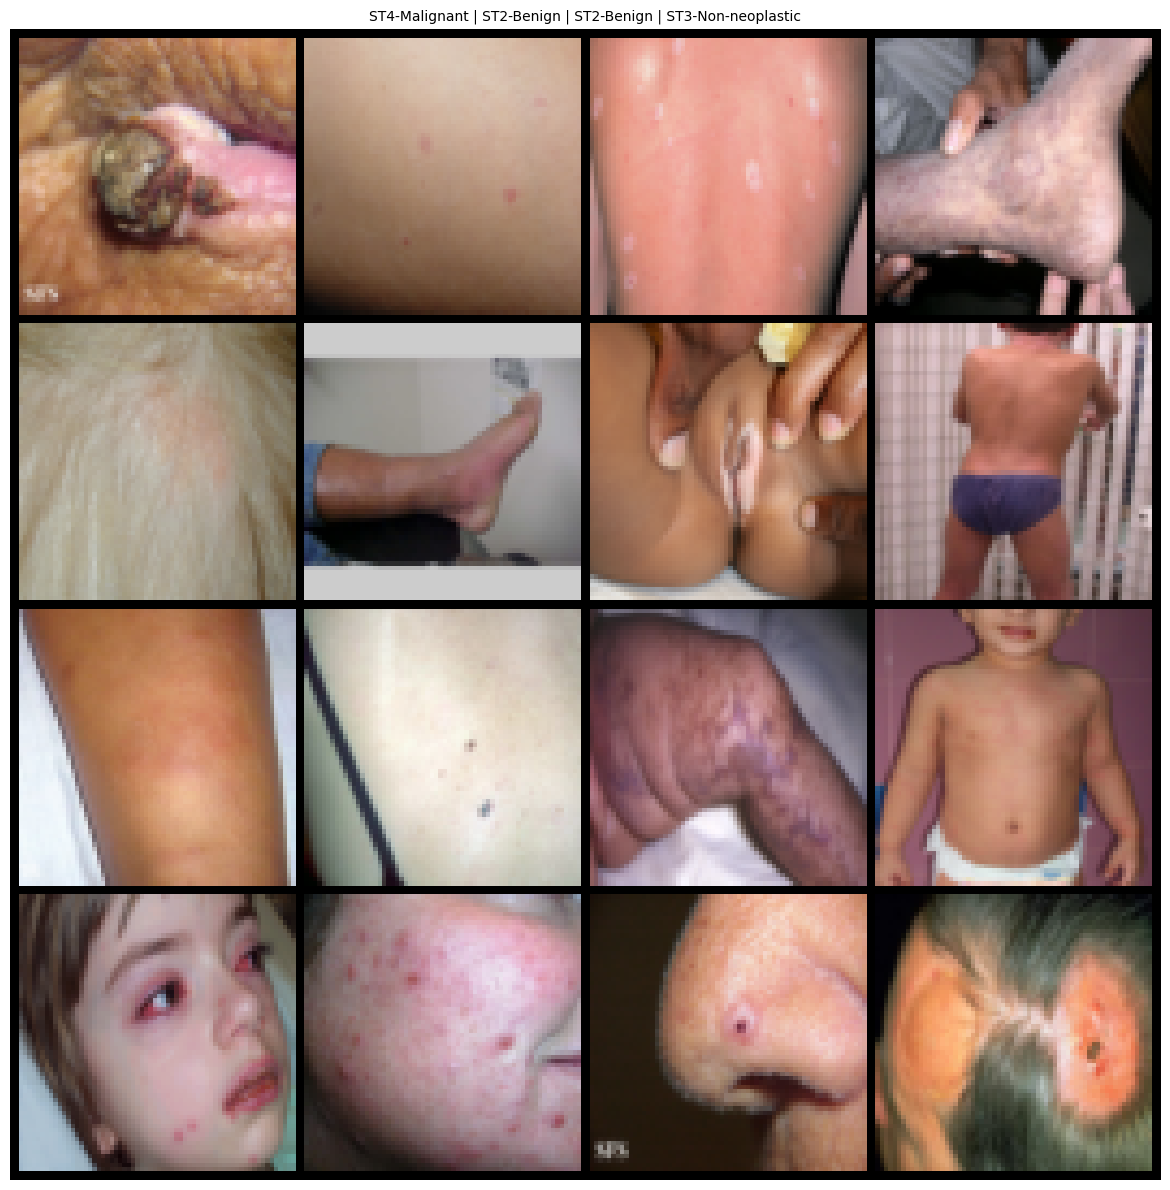

In [ ]:
# Example data paths (adjust to your setup)
CSV_PATH = "../dataset/fitzpatrick17k_cleaned.csv"
IMAGE_DIR = "../dataset/images"

# Note: You'll need to download the Fitzpatrick17k dataset first
# Instructions: https://github.com/mattgroh/fitzpatrick17k

# Uncomment to load and explore:
dataloader, dataset = get_dataloader(
    csv_path=CSV_PATH,
    image_dir=IMAGE_DIR,
    batch_size=32,
    num_workers=0
)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

# Load one batch
images, skin_tones, lesion_types = next(iter(dataloader))
print(f"Batch shapes: {images.shape}, {skin_tones.shape}, {lesion_types.shape}")

# Visualize
visualize_samples(images[:16], skin_tones[:16], lesion_types[:16], show=True)

### Example 2: Train the cGAN

In [ ]:
# Training configuration
LATENT_DIM = 100
EMBEDDING_DIM = 50
NGF = 64  # Generator base filters
NDF = 64  # Discriminator base filters
BATCH_SIZE = 64
EPOCHS = 200
LR = 0.0002
LABEL_SMOOTHING = 0.1
NOISE_STD = 0.1
NOISE_DECAY = 0.995

# Example training code

# Setup
device = get_device()
print(f"Using device: {device}")

# Load data
dataloader, dataset = get_dataloader(
    csv_path=CSV_PATH,
    image_dir=IMAGE_DIR,
    batch_size=BATCH_SIZE,
    num_workers=4,
    transform=get_augmented_transform()
)

# Create models
generator, discriminator = get_models(
    latent_dim=LATENT_DIM,
    embedding_dim=EMBEDDING_DIM,
    ngf=NGF,
    ndf=NDF,
    device=device
)

# Initialize weights
generator.apply(weights_init)
discriminator.apply(weights_init)

# Optimizers
optimizer_g = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

# Loss
criterion = nn.BCELoss()

# Setup logging
output_dir = Path("outputs") / datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir.mkdir(parents=True, exist_ok=True)
log_file = setup_logging(output_dir / "logs")

# Fixed samples for monitoring
fixed_noise = torch.randn(16, LATENT_DIM, device=device)
fixed_skin_tones = torch.tensor([i % NUM_SKIN_TONES for i in range(16)], device=device)
fixed_lesion_types = torch.tensor([i % NUM_LESION_TYPES for i in range(16)], device=device)

# Training loop
noise_std = NOISE_STD

for epoch in range(EPOCHS):
    # Train one epoch
    metrics = train_epoch(
        generator, discriminator, dataloader,
        optimizer_g, optimizer_d, criterion,
        device, LATENT_DIM,
        label_smoothing=LABEL_SMOOTHING,
        noise_std=noise_std
    )
    
    # Log
    log_msg = (
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"D_loss: {metrics['loss_d']:.4f}, G_loss: {metrics['loss_g']:.4f}, "
        f"D(x): {metrics['d_real']:.3f}, D(G(z)): {metrics['d_fake']:.3f}"
    )
    log_message(log_file, log_msg)
    
    # Decay noise
    noise_std *= NOISE_DECAY
    
    # Generate samples periodically
    if (epoch + 1) % 5 == 0:
        generator.eval()
        with torch.inference_mode():
            samples = generator(fixed_noise, fixed_skin_tones, fixed_lesion_types)
        
        save_path = output_dir / "samples" / f"epoch_{epoch+1:04d}.png"
        save_path.parent.mkdir(exist_ok=True)
        visualize_samples(samples, fixed_skin_tones, fixed_lesion_types, 
                         save_path=save_path, show=False)
        generator.train()
    
    # Save checkpoint
    if (epoch + 1) % 10 == 0:
        checkpoint_path = output_dir / "checkpoints" / f"checkpoint_{epoch+1:04d}.pt"
        checkpoint_path.parent.mkdir(exist_ok=True)
        save_checkpoint(
            generator, discriminator, optimizer_g, optimizer_d,
            epoch + 1, metrics, checkpoint_path
        )

# Save final model
final_path = output_dir / "checkpoints" / "final_model.pt"
save_checkpoint(
    generator, discriminator, optimizer_g, optimizer_d,
    EPOCHS, metrics, final_path
)
print(f"Training complete! Model saved to {final_path}")


### Example 3: Generate Synthetic Images

In [ ]:
# Example: Generate images after training
# Load trained generator
device = get_device()
generator = Generator(latent_dim=100, embedding_dim=50, ngf=64).to(device)
checkpoint = load_generator_only("path/to/checkpoint.pt", generator, device)
generator.eval()

# Generate samples for Fitzpatrick 5 & 6
output_dir = Path("generated_images")
output_dir.mkdir(exist_ok=True)

for skin_tone in [4, 5]:  # Indices for Fitzpatrick 5 & 6
    for lesion_type in range(3):
        # Generate 100 samples
        samples = generate_samples(
            generator, device, latent_dim=100,
            skin_tone=skin_tone,
            lesion_type=lesion_type,
            num_samples=100
        )
        
        # Save images
        class_dir = output_dir / f"st{skin_tone+1}_lt{lesion_type}"
        save_generated_images(
            samples, class_dir,
            prefix=f"st{skin_tone+1}_lt{lesion_type}"
        )
        
        print(f"Generated 100 images for ST{skin_tone+1}, LT{lesion_type}")

print("Generation complete!")

print("Generation code ready (uncomment to run after training)")

### Example 4: Visualize Results

In [ ]:
# Example: Visualize trained model outputs
# Load trained generator
device = get_device()
generator = Generator(latent_dim=100, embedding_dim=50, ngf=64).to(device)
load_generator_only("path/to/checkpoint.pt", generator, device)

# Visualize all combinations
visualize_conditional_grid(generator, device, latent_dim=100)

# Generate specific examples
samples = generate_samples(
    generator, device, latent_dim=100,
    skin_tone=5,  # Fitzpatrick 6
    lesion_type=0,  # Benign
    num_samples=16
)

visualize_samples(
    samples,
    torch.full((16,), 5),
    torch.full((16,), 0),
    show=True,
    nrow=4
)
